In [1]:
import numpy as np
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

(e)(f)

In [3]:
def maximize(g, a, b, args):
    """
    在区
    间[a, b]上最大化函数g。

    我们利用了这样一个事实：在任意区间上，g 的最大值点，同时也是 -g 的最小值点。
    参数元组 args 收集传递给 g 的额外参数。

    返回最大值和最大值点。
    """

    objective = lambda x: -g(x, *args)
    result = minimize_scalar(objective, bounds=(a, b), method='bounded')
    maximizer, maximum = result.x, -result.fun
    return maximizer, maximum

class SingleDepartment:
    def __init__(self,beta,H,a,theta,y_grid_min,y_grid_max,y_grid_size):
        self.beta=beta
        self.H=H
        self.a=a
        self.theta=theta
        self.y_grid = np.linspace(y_grid_min, y_grid_max, y_grid_size)
        self.gamma = theta[1]/ (1-a*beta)
        self.k = (1 / (1-beta))*(theta[0]*np.log(theta[1]/(theta[1]+beta*self.gamma*a))+ 
                            beta*self.gamma*a*np.log(a*beta)+
                            theta[0]*np.log(self.H)) 
        
    def u(self,c):
        theta = self.theta
        h = self.H
        return theta[0]*np.log(h)+theta[1]*np.log(c)
    
    def u_prime(self,c):
        theta = self.theta
        return theta[1] / c

    def state_action_value(self,c,y,v_array):
        # 一个timestop中当前状态y 和当期消费c可以计算贝尔曼方程的右侧        
        beta = self.beta
        u = self.u
        a =self.a 
        v = lambda y: np.interp(y,self.y_grid,v_array) #
        return u(c)+beta*v((y-c)**a)        
        
    def T(self,v):

        v_new = np.empty_like(v)
        c_memo = np.empty_like(v)
        for i, y in enumerate(self.y_grid):
        # 在状态 y 下最大化贝尔曼方程的右侧
            c_memo[i], v_new[i] = maximize(self.state_action_value, 1e-10, y, (y, v))
            # return maxmizer and maxmium
            # 每一个c要求是小于或等于当前存量 y 的
            # bootsrapping: 从已经有的V作为已知条件 c作为控制变量可以对贝尔曼方程左侧进行优化
            # 进行一次优化完成之后，再将新的价值函数作为已知条件进行下一步迭代
            # 多变量的函数对一个变量进行求解时，放在第一位，其余变量放在args = ( )函数读取参数从前往后
        return c_memo, v_new
    
    def v_star(self,y):
        gamma = self.gamma
        k = self.k
        return gamma*np.log(y)+k


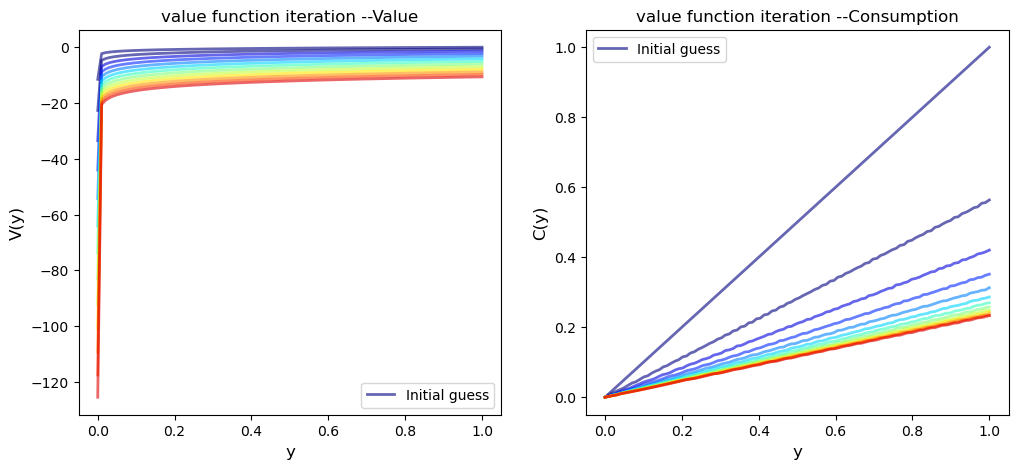

In [ ]:
fi = SingleDepartment(0.97,1,0.8,[1,0.5],1e-10,1,100)
# beta = 0.97, H=1, theta=[1,0.5], y0=1 y_grid[0,1],100 steps

y_grid = fi.y_grid
v = fi.u(y_grid)       # 初始猜测
n = 12                 # 迭代次数 前后两次变化可以用threshold 来确认收敛范围

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(y_grid, v, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Initial guess')

ax[1].plot(y_grid, y_grid, color=plt.cm.jet(0),
        lw=2, alpha=0.6, label='Initial guess')

for i in range(n):
    c,v = fi.T(v)  # 应用贝尔曼算子 返回每一次新计算出的消费策略 和 价值函数
    ax[0].plot(y_grid, v, color=plt.cm.jet(i / n), lw=2, alpha=0.6)
    ax[1].plot(y_grid, c, color=plt.cm.jet(i / n), lw=2, alpha=0.6)

ax[0].legend()
ax[0].set_ylabel('V(y)', fontsize=12)
ax[0].set_xlabel('y', fontsize=12)
ax[0].set_title('value function iteration --Value')

ax[1].legend()
ax[1].set_ylabel('C(y)', fontsize=12)
ax[1].set_xlabel('y', fontsize=12)
ax[1].set_title('value function iteration --Consumption')

plt.show()

In [28]:
def compute_value_function(fi,
                           tol=1e-4,
                           max_iter=1000,
                           verbose=True,
                           print_skip=25):

    # 设置循环
    v = np.zeros(len(fi.y_grid)) # 初始猜测
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:
        c_approxi, v_new = fi.T(v)

        error = np.max(np.abs(v - v_new))
        # 可以改变计算误差的方式 如使用MSE 误差的比较对象是上一次的迭代结果
        i += 1

        if verbose and i % print_skip == 0:
            print(f"第 {i} 次迭代的误差是 {error}.")

        v = v_new

    if error > tol:
        print("未能收敛！")
    elif verbose:
        print(f"\n在第 {i} 次迭代中收敛。")

    return c_approxi, v_new


第 25 次迭代的误差是 5.542520593422722.
第 50 次迭代的误差是 2.5882169204798515.
第 75 次迭代的误差是 1.2086318335754527.
第 100 次迭代的误差是 0.5644004942449214.
第 125 次迭代的误差是 0.26356075444545013.
第 150 次迭代的误差是 0.12307620562376087.
第 175 次迭代的误差是 0.057473474844982775.
第 200 次迭代的误差是 0.026838658975691487.
第 225 次迭代的误差是 0.012532974864598145.
第 250 次迭代的误差是 0.005852582243335291.
第 275 次迭代的误差是 0.0027330078680734005.
第 300 次迭代的误差是 0.0012762455436359232.
第 325 次迭代的误差是 0.0005959743865560085.
第 350 次迭代的误差是 0.00027830496350134126.
第 375 次迭代的误差是 0.00012996137832033128.

在第 384 次迭代中收敛。


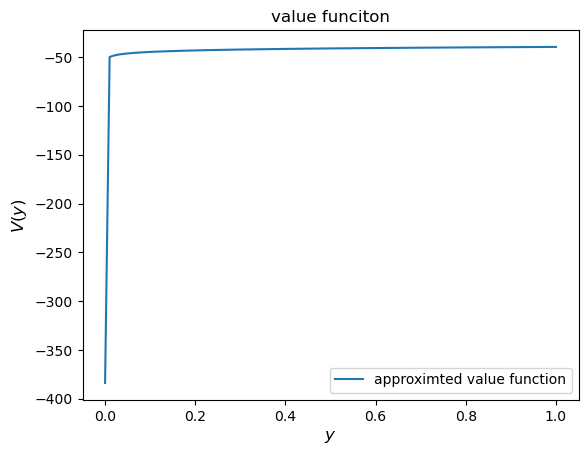

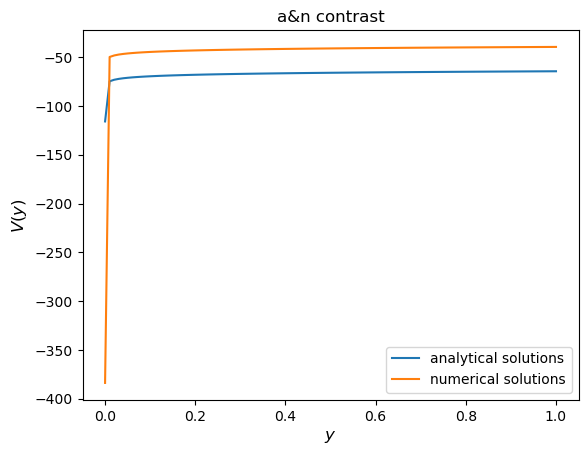

In [30]:
fi = SingleDepartment(0.97,1,0.8,[1,0.5],1e-10,1,100)
c, v = compute_value_function(fi)
fig, ax = plt.subplots()

ax.plot(y_grid, v, label='approximted value function')
ax.set_ylabel('$V(y)$', fontsize=12)
ax.set_xlabel('$y$', fontsize=12)
ax.set_title('value funciton')
ax.legend()
plt.show()
v_analytical = fi.v_star(y_grid)
fig, ax = plt.subplots()

ax.plot(y_grid, v_analytical, label='analytical solutions')
ax.plot(y_grid, v, label='numerical solutions')
ax.set_ylabel('$V(y)$', fontsize=12)
ax.set_xlabel('$y$', fontsize=12)
ax.legend()
ax.set_title('a&n contrast')
plt.show()

(g)

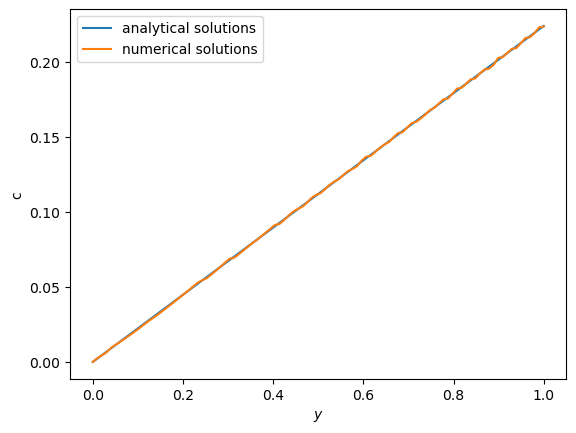

In [42]:

def c_star(fi):
    A = fi.theta[1]/(fi.theta[1]+fi.beta*fi.gamma*fi.a)
    return A*fi.y_grid

c_analytical = c_star(fi)

fig, ax = plt.subplots()

ax.plot(fi.y_grid, c_analytical, label='analytical solutions')
ax.plot(fi.y_grid, c, label='numerical solutions')
ax.set_ylabel('c')
ax.set_xlabel('$y$')
ax.legend()

plt.show()

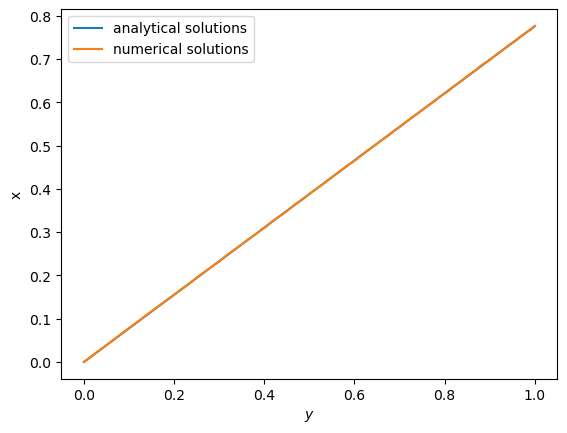

In [41]:
x = fi.y_grid - c
def x_star(fi):
    A = (fi.beta*fi.gamma*fi.a)/(fi.theta[1]+fi.beta*fi.gamma*fi.a)
    return A*fi.y_grid

x_analytical = x_star(fi)

fig, ax = plt.subplots()

ax.plot(fi.y_grid, x_analytical, label='analytical solutions')
ax.plot(fi.y_grid, x, label='numerical solutions')
ax.set_ylabel('x')
ax.set_xlabel('$y$')
ax.legend()

plt.show()

$Z^{*}(Y) = H$

(h)

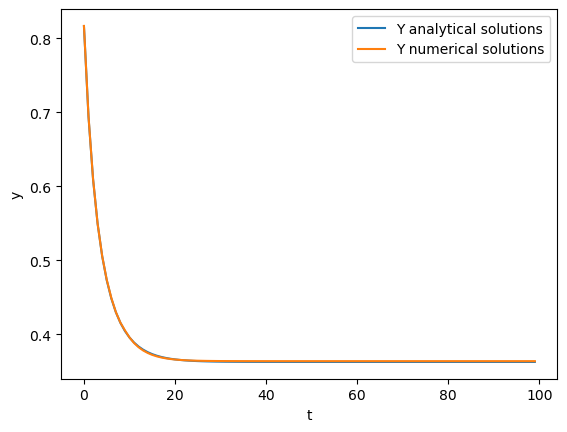

In [39]:
A = fi.theta[1]/(fi.theta[1]+fi.beta*fi.gamma*fi.a)
def y_analytical_path(t,a):
    y_temp = 1
    lis = []
    for i in t:
        y_temp = ((1-A)*y_temp)**a
        lis.append(y_temp)
    return np.array(lis)

def c_analytical_path(y_path):
    return A*y_path

def c_numerical(y_grid,c,y):
    return np.interp(y,y_grid,c)

t = [_ for _ in range(100)]
fig, ax = plt.subplots()
y_numerical_path = []
c_numerical_path = []
y_temp = 1
for _ in t:
    c_temp = c_numerical(fi.y_grid,c,y_temp)
    y_temp = (y_temp - c_temp)**fi.a
    y_numerical_path.append(y_temp)
    c_numerical_path.append(c_temp)

ax.plot(t, y_analytical_path(t,fi.a), label='Y analytical solutions')
ax.plot(t, y_numerical_path, label='Y numerical solutions')
ax.set_ylabel('y')
ax.set_xlabel('t')
ax.legend()

plt.show()

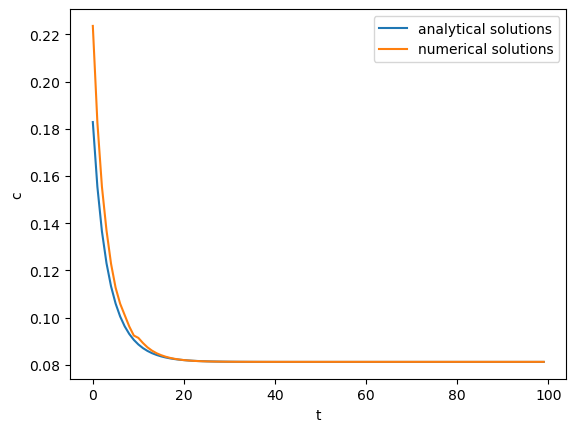

In [40]:
fig, ax = plt.subplots()

ax.plot(t, c_analytical_path(y_analytical_path(t,fi.a)), label='analytical solutions')
ax.plot(t, c_numerical_path, label='numerical solutions')
ax.set_ylabel('c')
ax.set_xlabel('t')
ax.legend()

plt.show()